# Multi-Start Training (Random Restarts)

Runs N random parameter initializations for a short burn-in period,
then continues training with the best-performing initialization.

This addresses the non-convex loss landscape: different starting points explore
different basins, and we select the most promising one before investing full training budget.

In [1]:
import logging

import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np
from jax import config

from ADoptEX.core.data import crop_to_stim_window, load_trace
from ADoptEX.core.parameters import DEFAULT_PARAMS, PARAM_BOUNDS, NAUD_PARAMETERS
from ADoptEX.core.simulation import simulate_jaxley
from ADoptEX.evaluation.coincidence import coincidence_factor
from ADoptEX.loss import (
    make_soft_dtw_loss_fn,
    SoftDTWLossConfig,
    make_guarino_loss_fn,
    GuarinoFeatures,
    extract_experimental_features,
    guarino_loss,
    GuarinoLossConfig,
)
from ADoptEX.loss.mse import MSELossConfig, make_mse_loss_fn
from ADoptEX.plotting import (
    fit_before_after_plot,
    fit_comparison_plot,
    parameter_comparison_plot,
    spike_timing_plot,
    trace_plot,
    trace_stim_window_plot,
    training_comparison_plot,
    training_history_plot,
)
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell, train

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

## 1. Load Data

In [2]:
DATA_DIR = "/Users/paulmayer/Projects/university/40_thesis/4_data/models/optimisations/mCP-dspn-e150917_c6_D1-manimal_1_n24_04102017_cel1/expdata/"

trace = load_trace(
    voltage_path=DATA_DIR + "ECBL_IDthresh_ch5_553.dat",
    current_path=DATA_DIR + "ECBL_IDthresh_ch4_553.dat",
)

print(
    f"Loaded trace: {trace.n_samples} samples, dt={trace.dt_ms:.3f} ms, duration={trace.duration_ms:.1f} ms"
)
print(
    f"Stim window: {trace.stim_start_idx} - {trace.stim_end_idx} ({trace.stim_duration_ms:.1f} ms)"
)
print(f"Stim current: {trace.stim_current_pA:.1f} pA")
print(f"Detected spikes: {trace.n_spikes}")

Loaded trace: 30000 samples, dt=0.100 ms, duration=2999.9 ms
Stim window: 7001 - 27001 (2000.0 ms)
Stim current: 421.3 pA
Detected spikes: 46


Cropped trace: 5000 samples, 500.0 ms
Spikes in window: 13 at [ 35.   72.  109.3 147.6 181.6 218.1 253.3 292.8 330.2 366.2 399.5 437.2
 475.1] ms


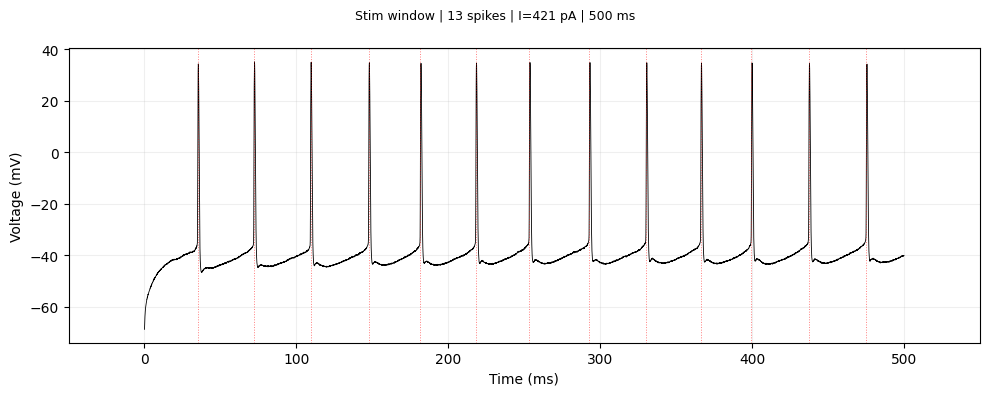

In [3]:
# Crop to stimulation window (500 ms max)
data = crop_to_stim_window(trace, max_duration_ms=500.0)

print(f"Cropped trace: {data.n_samples} samples, {data.stim_duration_ms:.1f} ms")
print(f"Spikes in window: {data.n_spikes} at {data.spike_times.round(1)} ms")

trace_stim_window_plot(data);

## 2. Initial Simulation

INFO:2026-02-14 12:00:26,522:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Initial simulation: 8 spikes, firing rate 13.3 Hz
Experimental:       13 spikes


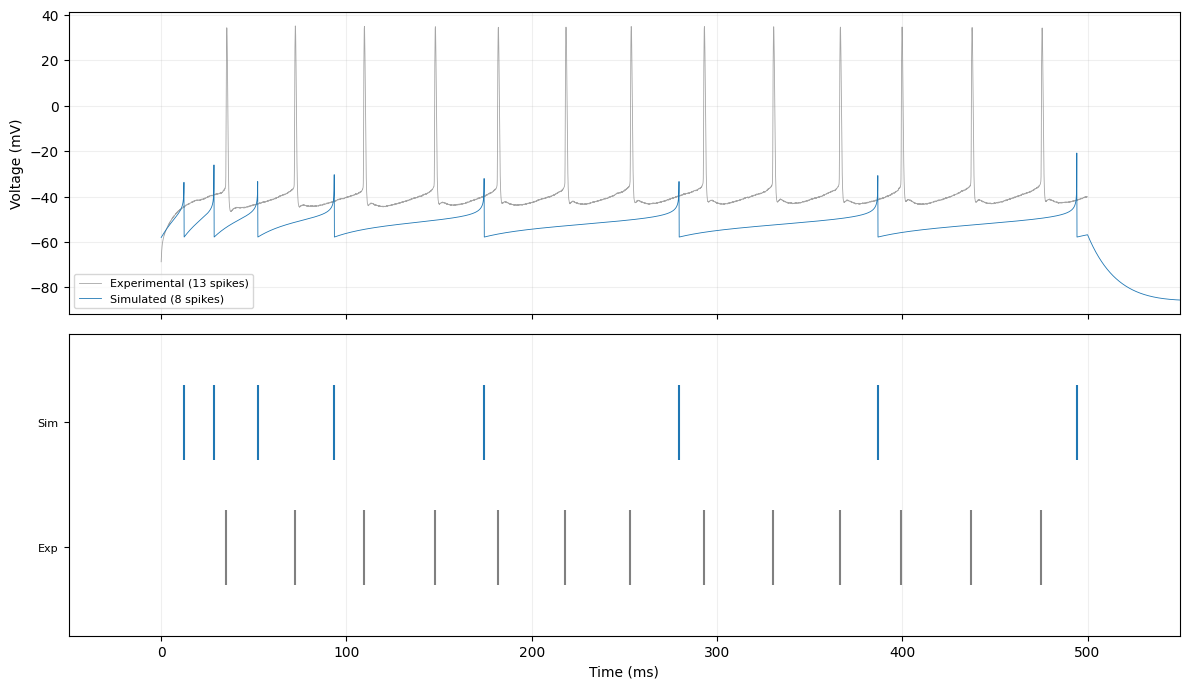

In [4]:
initial_params = dict(NAUD_PARAMETERS["adaptation"])
initial_params["v_threshold"] = 0.0  # required by create_adex_cell

sim_init = simulate_jaxley(
    params=initial_params,
    stim_current_pA=data.stim_current_pA,
    stim_duration_ms=data.stim_duration_ms,
    dt_ms=data.dt_ms,
    use_surrogate=True,
)

print(
    f"Initial simulation: {sim_init.n_spikes} spikes, firing rate {sim_init.firing_rate_hz:.1f} Hz"
)
print(f"Experimental:       {data.n_spikes} spikes")

fit_comparison_plot(data, sim_init);

## 3. Multi-Start Burn-In

Generate N random parameter sets by sampling uniformly from `PARAM_BOUNDS`,
then train each for a short burn-in period.

In [5]:
# Convert current trace to nA (Jaxley units, scaled by C_m)
current_nA = jnp.array(data.current * initial_params["C_m"] / 1000.0)
target_voltage = jnp.array(data.voltage)
stim_end_index = data.stim_end_idx

# Trainable parameter names
TRAINABLE = ["g_L", "E_L", "v_T", "v_reset", "tau_w", "a", "b"]


def sample_random_params(key, base_params, trainable=TRAINABLE):
    """Sample random values for trainable params within PARAM_BOUNDS."""
    params = dict(base_params)
    keys = jr.split(key, len(trainable))
    for k, name in zip(keys, trainable):
        b = PARAM_BOUNDS[name]
        params[name] = float(jr.uniform(k, minval=b.min, maxval=b.max))
    return params

In [6]:
N_STARTS = 10
BURN_IN_EPOCHS = 50

burn_in_config = TrainingConfig(
    optimizer="polyak",
    learning_rate=0.005,
    n_epochs=BURN_IN_EPOCHS,
    surrogate_type="sigmoid",
    surrogate_slope=5.0,
    print_every=BURN_IN_EPOCHS,  # only print at end
    polyak_alpha=1.0,
    polyak_beta=1.0,
    clip_to_bounds=True,
    verbose=False,
    return_best=True,
)

# Extract target features for Guarino loss
exp_features = extract_experimental_features(
    voltage_trace=target_voltage,
    dt_ms=data.dt_ms,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=stim_end_index,
)

guarino_config = GuarinoLossConfig(
    weight_t_first=25.0,
    weight_t_last=5.0,
    weight_firing_freq=10.0,
    weight_spike_count=1.0,
)

# --- Burn-in loop ---
key = jr.PRNGKey(42)
keys = jr.split(key, N_STARTS)

burn_in_results = []
print(f"Running {N_STARTS} random starts x {BURN_IN_EPOCHS} epochs burn-in...\n")

for i, k in enumerate(keys):
    params_i = sample_random_params(k, initial_params)

    cell_i, stim_i, tmax_i, tp_i = setup_trainable_cell(
        initial_params=params_i,
        current_trace_nA=current_nA,
        dt_ms=data.dt_ms,
        config=burn_in_config,
    )

    loss_fn_i = make_guarino_loss_fn(
        cell=cell_i,
        data_stimuli=stim_i,
        t_max=tmax_i,
        dt_ms=data.dt_ms,
        exp_features=exp_features,
        stim_duration_ms=data.stim_duration_ms,
        stim_end_index=stim_end_index,
        loss_config=guarino_config,
    )

    result_i = train(
        loss_fn=loss_fn_i,
        trainable_params=tp_i,
        config=burn_in_config,
        initial_params=params_i,
    )

    burn_in_results.append((params_i, result_i))
    print(
        f"  Start {i:>2d}: best_loss={result_i.best_loss:.4f}  final_loss={result_i.final_loss:.4f}"
    )

# Select best
best_idx = min(range(N_STARTS), key=lambda j: burn_in_results[j][1].best_loss)
best_init_params, best_burn_result = burn_in_results[best_idx]

print(f"\nBest start: #{best_idx} with loss={best_burn_result.best_loss:.4f}")

Running 10 random starts x 50 epochs burn-in...

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7


Epoch    0 | loss=89.336510 | grad_norm=2.14e-02 | lr=4.47e-01 | g_L=12.3871, E_L=-73.0209, v_T=-59.1080, v_reset=-75.4629, tau_w=293.7025, a=5.5024, b=129.2145


  Start  0: best_loss=83.8293  final_loss=83.8293
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7


Epoch    0 | loss=282.960632 | grad_norm=6.59e-02 | lr=1.41e+00 | g_L=11.1434, E_L=-83.5072, v_T=-43.2865, v_reset=-60.5739, tau_w=440.5475, a=2.7331, b=119.7306


  Start  1: best_loss=42.6997  final_loss=44.4101
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7


...

  Start  7: best_loss=31.0557  final_loss=31.0641
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7


Epoch    0 | loss=282.769043 | grad_norm=3.46e-02 | lr=1.41e+00 | g_L=16.2432, E_L=-65.1250, v_T=-40.6937, v_reset=-71.8867, tau_w=442.8017, a=7.2388, b=28.1688


  Start  8: best_loss=25.3972  final_loss=33.7043
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7


Epoch    0 | loss=69.619011 | grad_norm=2.03e-02 | lr=3.48e-01 | g_L=31.2689, E_L=-53.4825, v_T=-50.6017, v_reset=-57.8585, tau_w=465.6925, a=9.4429, b=125.4195


  Start  9: best_loss=67.0382  final_loss=80.6765

Best start: #4 with loss=23.9371


In [7]:
# Burn-in summary table
print(f"{'Start':>5} | {'Best Loss':>10} | {'Final Loss':>10}")
print("-" * 35)
for i, (_, res) in enumerate(burn_in_results):
    marker = " <-- best" if i == best_idx else ""
    print(f"{i:>5d} | {res.best_loss:>10.4f} | {res.final_loss:>10.4f}{marker}")

Start |  Best Loss | Final Loss
-----------------------------------
    0 |    83.8293 |    83.8293
    1 |    42.6997 |    44.4101
    2 |    52.9975 |    53.7559
    3 |    35.1368 |    36.1169
    4 |    23.9371 |    25.5588 <-- best
    5 |    70.8312 |    71.5833
    6 |    64.5244 |    67.5427
    7 |    31.0557 |    31.0641
    8 |    25.3972 |    33.7043
    9 |    67.0382 |    80.6765


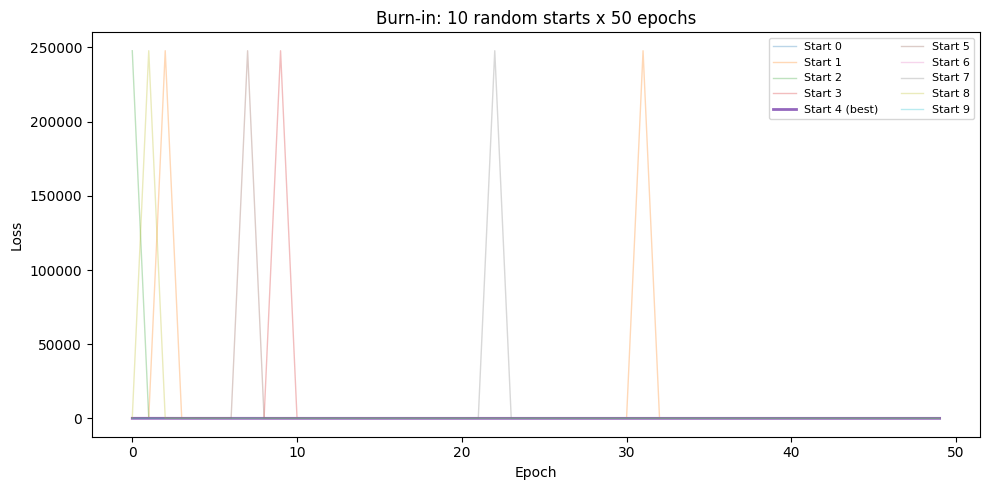

In [8]:
# Overlay burn-in loss curves
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
for i, (_, res) in enumerate(burn_in_results):
    alpha = 1.0 if i == best_idx else 0.3
    lw = 2.0 if i == best_idx else 1.0
    label = f"Start {i} (best)" if i == best_idx else f"Start {i}"
    ax.plot(res.loss_history, alpha=alpha, lw=lw, label=label)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"Burn-in: {N_STARTS} random starts x {BURN_IN_EPOCHS} epochs")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 4. Continue Training with Best Initialization

In [9]:
# Extract best params from burn-in and continue training
best_trained = best_burn_result.get_params_dict()
continue_params = dict(initial_params)
continue_params.update(best_trained)

print("Best burn-in parameters:")
for k, v in best_trained.items():
    print(f"  {k:<12} {v:>10.3f}")

# Continue training config — more epochs
continue_config = TrainingConfig(
    optimizer="polyak",
    learning_rate=0.005,
    n_epochs=200,
    surrogate_type="sigmoid",
    surrogate_slope=5.0,
    print_every=50,
    polyak_alpha=1.0,
    polyak_beta=1.0,
    clip_to_bounds=True,
    verbose=True,
    return_best=True,
)

cell_cont, stim_cont, tmax_cont, tp_cont = setup_trainable_cell(
    initial_params=continue_params,
    current_trace_nA=current_nA,
    dt_ms=data.dt_ms,
    config=continue_config,
)

loss_fn_cont = make_guarino_loss_fn(
    cell=cell_cont,
    data_stimuli=stim_cont,
    t_max=tmax_cont,
    dt_ms=data.dt_ms,
    exp_features=exp_features,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=stim_end_index,
    loss_config=guarino_config,
)

result_continue = train(
    loss_fn=loss_fn_cont,
    trainable_params=tp_cont,
    config=continue_config,
    initial_params=continue_params,
)

print(f"\nContinued training complete.")
print(f"  Best loss:   {result_continue.best_loss:.4f}")
print(f"  Total time:  {result_continue.total_time:.1f} s")

Training: optimizer=polyak lr=0.005 epochs=200 surrogate=sigmoid slope=5.0 alpha=1.0 beta=1.0


Best burn-in parameters:
  g_L              23.465
  E_L             -52.551
  v_T             -46.667
  v_reset         -73.782
  tau_w           281.498
  a                 8.479
  b                62.116
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7


Epoch    0 | loss=23.827375 | grad_norm=2.34e-02 | lr=1.19e-01 | g_L=23.4978, E_L=-52.5521, v_T=-46.5535, v_reset=-73.7669, tau_w=281.4983, a=8.4793, b=62.1139
Epoch   50 | loss=25.094685 | grad_norm=9.84e+00 | lr=1.25e-01 | g_L=24.1134, E_L=-51.5850, v_T=-45.5402, v_reset=-72.5106, tau_w=281.4729, a=8.4296, b=61.9348
Epoch  100 | loss=24.485477 | grad_norm=2.09e-02 | lr=1.22e-01 | g_L=24.5163, E_L=-50.8281, v_T=-44.2494, v_reset=-71.1268, tau_w=281.4624, a=8.4086, b=61.8209
Epoch  150 | loss=24.007504 | grad_norm=2.10e-02 | lr=1.20e-01 | g_L=24.7737, E_L=-50.0000, v_T=-43.1479, v_reset=-70.3568, tau_w=281.4108, a=8.2848, b=61.5137
Training complete: final_loss=24.076366 best_loss=23.309650 (epoch 119) total_time=152.7s mean_epoch=763.4ms lr=1.19e-01->1.20e-01 [returning best]



Continued training complete.
  Best loss:   23.3097
  Total time:  152.7 s


## 5. Results

In [10]:
# Show trained parameter values
trained_final = result_continue.get_params_dict()
print("Final trained parameters:")
print(f"{'Parameter':<12} {'Initial':>10} {'Burn-in':>10} {'Final':>10} {'Bounds':>20}")
print("-" * 65)
for k in trained_final:
    init_v = initial_params.get(k, float("nan"))
    burn_v = best_trained.get(k, float("nan"))
    final_v = trained_final[k]
    bounds = PARAM_BOUNDS.get(k)
    bounds_str = f"[{bounds.min}, {bounds.max}]" if bounds else ""
    print(f"{k:<12} {init_v:>10.3f} {burn_v:>10.3f} {final_v:>10.3f} {bounds_str:>20}")

Final trained parameters:
Parameter       Initial    Burn-in      Final               Bounds
-----------------------------------------------------------------
g_L              12.000     23.465     24.574          [1.0, 50.0]
E_L             -70.000    -52.551    -50.000       [-90.0, -50.0]
v_T             -50.000    -46.667    -43.906       [-60.0, -40.0]
v_reset         -58.000    -73.782    -70.938       [-80.0, -50.0]
tau_w           300.000    281.498    281.428        [10.0, 500.0]
a                 2.000      8.479      8.322          [0.0, 10.0]
b                60.000     62.116     61.670         [0.0, 200.0]


In [11]:
# Final simulation
params_final = dict(initial_params)
params_final.update(trained_final)

sim_final = simulate_jaxley(
    params=params_final,
    stim_current_pA=data.stim_current_pA,
    stim_duration_ms=data.stim_duration_ms,
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Final simulation: {sim_final.n_spikes} spikes (target: {data.n_spikes})")

if sim_final.n_spikes > 0 and data.n_spikes > 0:
    cf = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_final.spike_times,
        duration_ms=data.stim_duration_ms,
    )
    print(f"Coincidence factor Gamma = {cf.gamma:.3f} (target > 0.5)")
else:
    cf = None
    print("Coincidence factor: N/A (no spikes)")

/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:87: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
Final simulation: 12 spikes (target: 13)
Coincidence factor Gamma = -0.110 (target > 0.5)


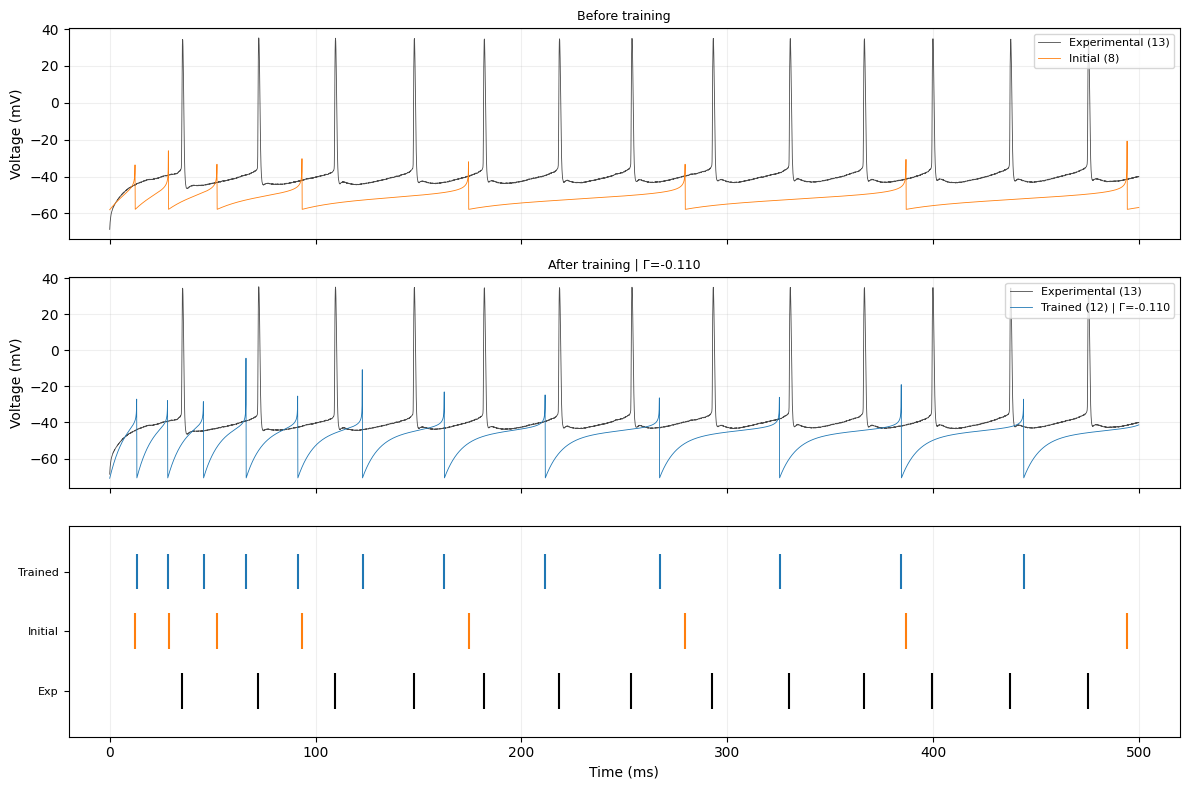

In [12]:
fit_before_after_plot(data, sim_init, sim_final, coincidence=cf);

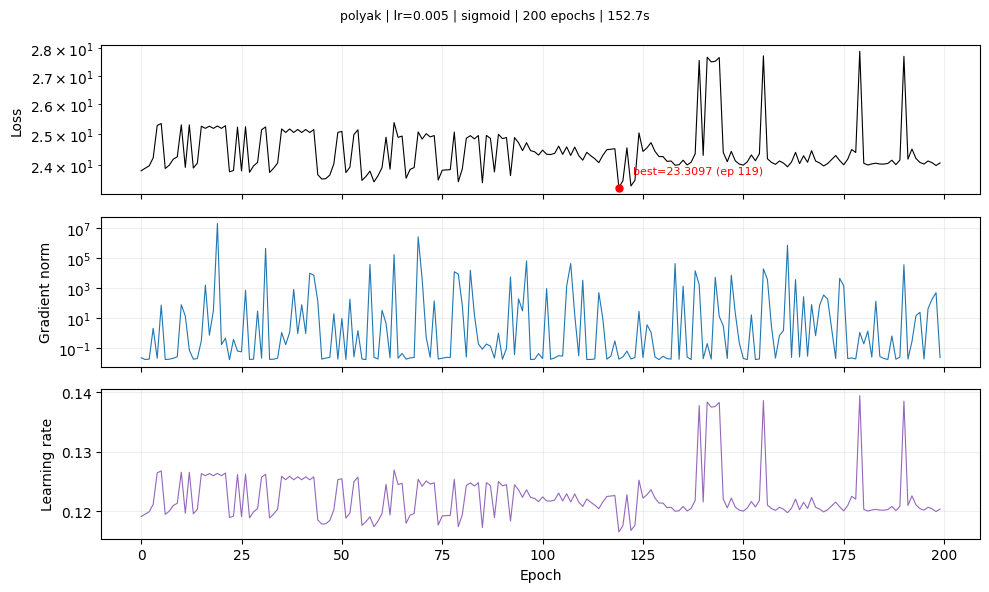

In [13]:
training_history_plot(result_continue);

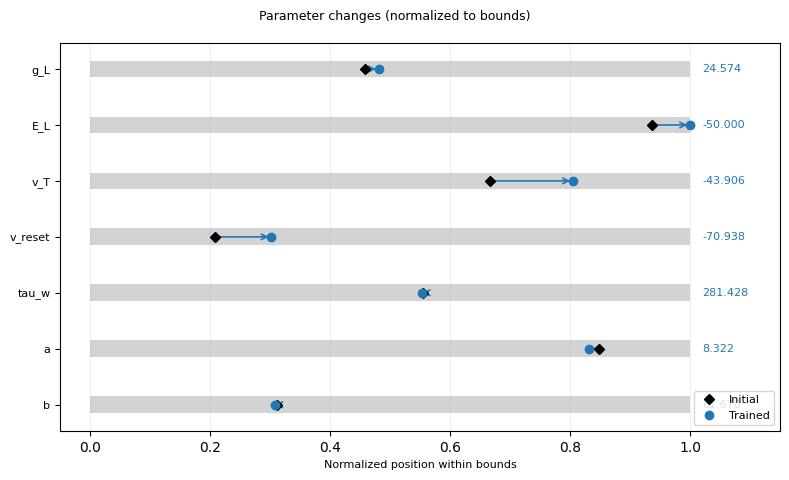

In [14]:
parameter_comparison_plot(result_continue);

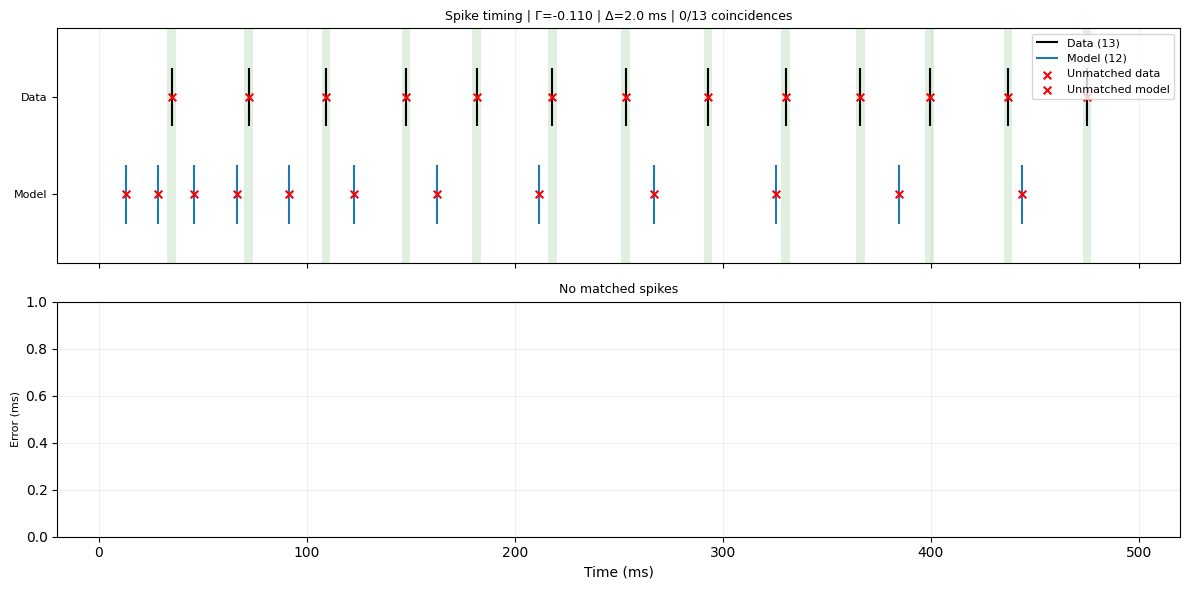

In [15]:
if cf is not None:
    spike_timing_plot(data, sim_final, cf)
else:
    print("Spike timing plot skipped (no spikes)")